In [1]:
import pandas as pd

# Load the data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Quick overview
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print("\n--- Target Distribution ---")
print(train['Heart Disease'].value_counts(normalize=True))
print("\n--- Missing Values ---")
print(train.isnull().sum().sum())
print("\n--- Feature Types ---")
print(train.dtypes.value_counts())

Train shape: (630000, 15)
Test shape: (270000, 14)

--- Target Distribution ---
Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64

--- Missing Values ---
0

--- Feature Types ---
int64      13
float64     1
object      1
Name: count, dtype: int64


In [5]:
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [6]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('train.csv')

# 2. Drop the ID column immediately (replace 'id_column_name' with your actual column name)
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# 3. Save the Baseline Dataset (No Interactions)
df.to_csv('train_baseline.csv', index=False)
print("Saved baseline dataset.")

# 4. Generate Interaction Features
# Based on your previous correlation table, we'll combine strong predictors
df_interactions = df.copy()

# Example interactions (adjust based on your EDA insights):
# Age combined with Max HR (since Max HR decreases with age and had a strong negative correlation)
df_interactions['Age_x_Max_HR'] = df_interactions['Age'] * df_interactions['Max HR']

# Chest pain combined with Exercise Angina (both highly correlated with the target)
df_interactions['ChestPain_x_Angina'] = df_interactions['Chest pain type'] * df_interactions['Exercise angina']

# Blood Pressure and Cholesterol 
df_interactions['BP_x_Cholesterol'] = df_interactions['BP'] * df_interactions['Cholesterol']

# 5. Save the Dataset with Interactions
df_interactions.to_csv('train_interactions.csv', index=False)
print("Saved interactions dataset.")

Saved baseline dataset.
Saved interactions dataset.


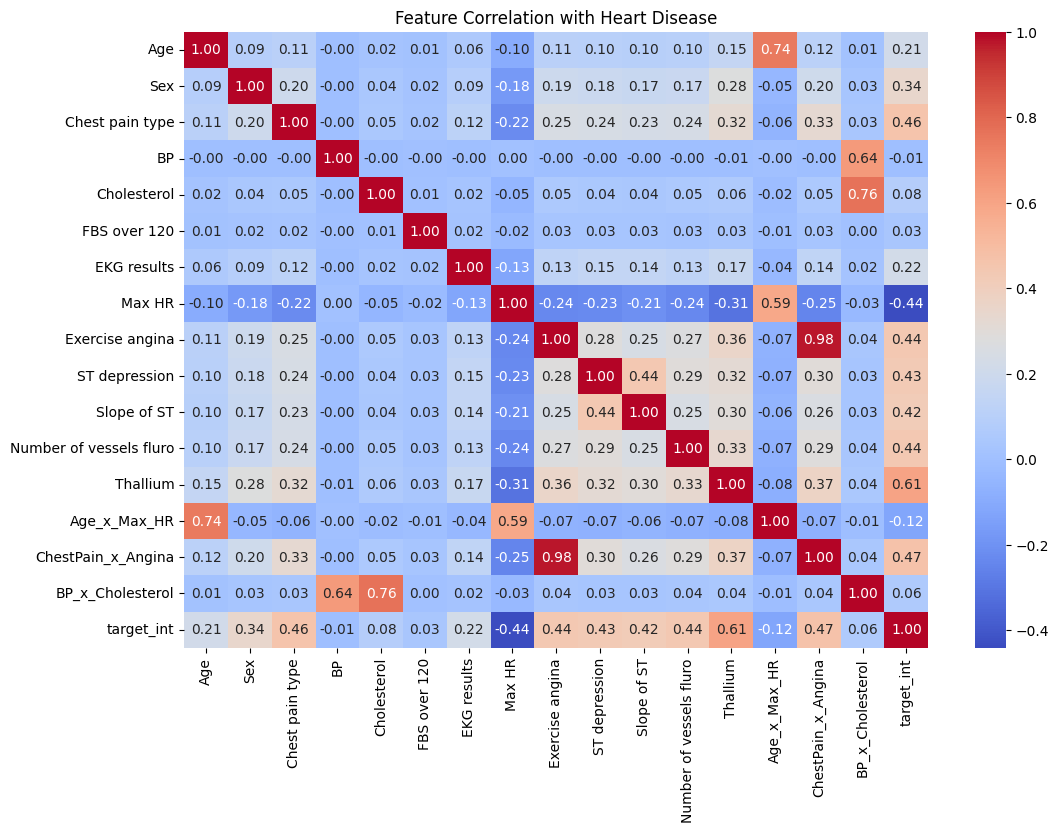

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identify numeric columns for correlation
# We exclude 'id' if it exists, as it's just a sequence
numeric_cols = df_interactions.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numeric_cols: numeric_cols.remove('id')

# Correlation with the target
# Note: Since the target 'Heart Disease' is an 'object', we map it to 0/1 for the heatmap
df_interactions['target_int'] = df_interactions['Heart Disease'].map({'Absence': 0, 'Presence': 1})

plt.figure(figsize=(12, 8))
sns.heatmap(df_interactions[numeric_cols + ['target_int']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation with Heart Disease")
plt.show()

# Drop the temporary column after checking
df_interactions.drop(columns=['target_int'], inplace=True)

In [3]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Number of GPUs available: {torch.cuda.device_count()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

CUDA Available: True
Number of GPUs available: 1
GPU Name: NVIDIA GeForce RTX 3070 Laptop GPU


In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor

# 1. Define the label and evaluation metric
label = 'Heart Disease'
eval_metric = 'roc_auc'  # This is crucial for this Kaggle competition

# 2. Initialize the Predictor
# We set 'eval_metric' to roc_auc so it optimizes for probabilities
predictor = TabularPredictor(
    label=label, 
    eval_metric=eval_metric,
    path='autogluon_heart_disease'
).fit(
    train_data=train,
    time_limit=3600,      # 1 hour limit; increase this if you have time
    presets='best_quality', # Enables stacking and bagging (best for Kaggle)
    num_stack_levels=1    # Good balance between performance and time
)

# 3. Check model performance on training (cross-validated)
performance = predictor.leaderboard(train, silent=True)
print(performance)

In [1]:
import pandas as pd
from autogluon.tabular import TabularPredictor

# --- 1. Load the Test Data ---
# Replace 'test.csv' with your actual test file name
test_df = pd.read_csv('test.csv')

# Extract the ID column for the submission file
# Replace 'id' with the actual ID column name if it's different in your dataset
submission_ids = test_df['id']

# --- 2. Prepare Data for the Baseline Model ---
# The baseline model expects the raw data without the ID column
test_baseline = test_df.drop(columns=['id'])

# --- 3. Prepare Data for the Interactions Model ---
# This dataset MUST have the exact same interaction columns you created for training
test_interactions = test_df.drop(columns=['id']).copy()

# Recreate the exact same interactions you used in your training script:
test_interactions['Age_x_Max_HR'] = test_interactions['Age'] * test_interactions['Max HR']
test_interactions['ChestPain_x_Angina'] = test_interactions['Chest pain type'] * test_interactions['Exercise angina']
test_interactions['BP_x_Cholesterol'] = test_interactions['BP'] * test_interactions['Cholesterol']

# --- 4. Load the Trained Models ---
print("Loading models...")
predictor_base = TabularPredictor.load("ag_models/Baseline_Model")
predictor_interact = TabularPredictor.load("ag_models/Interaction_Model")

# Identify the positive class (Usually 1 or 'Yes')
positive_class = predictor_base.positive_class

# --- 5. Generate Probabilities ---
print("Generating predictions...")
# predict_proba returns a dataframe with probabilities for both classes. 
# We extract the column corresponding to the positive class.
preds_base = predictor_base.predict_proba(test_baseline)[positive_class]
preds_interact = predictor_interact.predict_proba(test_interactions)[positive_class]

# --- 6. Create Submission Files ---
# Create DataFrames matching Kaggle's required format
sub_base = pd.DataFrame({
    'id': submission_ids,
    'Heart Disease': preds_base
})

sub_interact = pd.DataFrame({
    'id': submission_ids,
    'Heart Disease': preds_interact
})

# --- 7. Save to CSV ---
sub_base.to_csv('submission_baseline.csv', index=False)
sub_interact.to_csv('submission_interactions.csv', index=False)

print("Submissions created successfully!")
print("- Saved: submission_baseline.csv")
print("- Saved: submission_interactions.csv")

d:\Sharan\College\Kaggle Competitions\.autogluonenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models...
Generating predictions...
Submissions created successfully!
- Saved: submission_baseline.csv
- Saved: submission_interactions.csv


In [2]:
predictor_base.leaderboard(train, silent=True)

NameError: name 'train' is not defined